In [1]:
import os
os.environ["R_HOME"] = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/R"

qiime_env = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1"
os.environ["PATH"] = f"{qiime_env}/bin:/usr/local/bin:/usr/bin:/bin"
os.environ["CONDA_PREFIX"] = qiime_env


In [2]:
from ancombc2_heatmaps import (
    TaxonTrajectoryPlotter,
    TrajectoryConfig,
    TrajectoryMetadataConfig,
    TrajectoryPathConfig,
    TrajectoryPlotConfig,
)

print("Import ok")

Import ok


In [3]:
TIMEPOINTS = ["baseline1", "baseline2", "baseline3", "day1", "day3", "day7", "day14"]

TIMEPOINT_NUMERIC_MAP = {
    "baseline_1": -7,
    "baseline_2": -4,
    "baseline_3": -1,
    "day_1_post": 1,
    "day_3_post": 3,
    "day_7_post": 7,
    "day_14_post": 14,
    "baseline1": -7,
    "baseline2": -4,
    "baseline3": -1,
    "day1": 1,
    "day3": 3,
    "day7": 7,
    "day14": 14,
}

TP_LABEL_MAP = {
    0: "baseline",
    -7: "baseline1",
    -4: "baseline2",
    -1: "baseline3",
    1: "day1",
    3: "day3",
    7: "day7",
    14: "day14",
}

In [4]:
config = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/metadata_microbian2_26.02.2026.txt",
        table_base="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex",
        ancom_base="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=True,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={
            "female": "",
            "male": (4, 2),
        },
        figsize=(12, 8),
    ),
)

print("Config ok")

Config ok


In [5]:
plotter = TaxonTrajectoryPlotter(config)
meta = plotter.load_metadata()

print(meta.shape)
print(meta[["sample_name", "time_point", "sex", "mice_model", "description_of_treatment"]].head())

(544, 73)
                     sample_name  time_point   sex mice_model  \
0    16320.zr22868.68V3V4.S68.R1  baseline_1  male        Apc   
1    16320.zr22868.91V3V4.S95.R1  baseline_2  male        Apc   
2  16320.zr22868.391V3V4.S407.R1  baseline_1  male        Apc   
3  16320.zr22868.407V3V4.S427.R1  baseline_2  male        Apc   
4  16320.zr22868.227V3V4.S235.R1  baseline_1  male        Apc   

  description_of_treatment  
0                     sham  
1                     sham  
2                     sham  
3                     sham  
4                     sham  


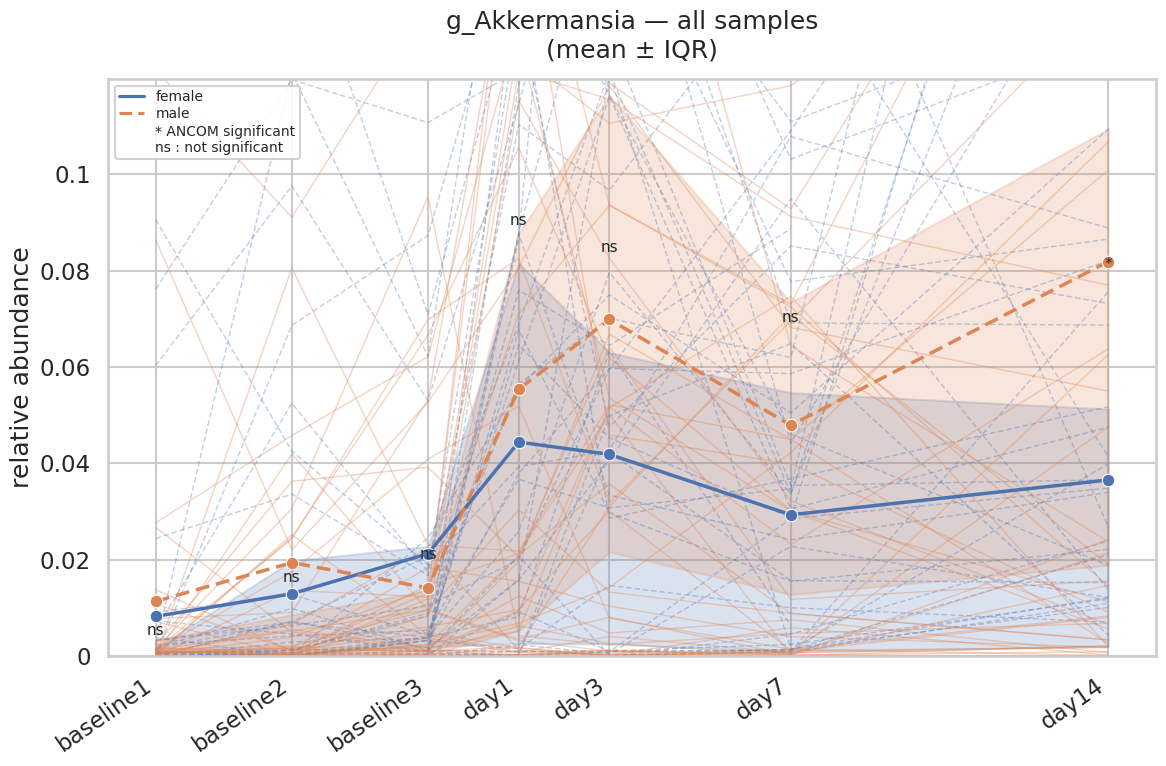

In [6]:
plotter.plot_taxon(
    taxon_query="g_Akkermansia",
    plot_mode="full",
    comparison_levels=["female", "male"],
)

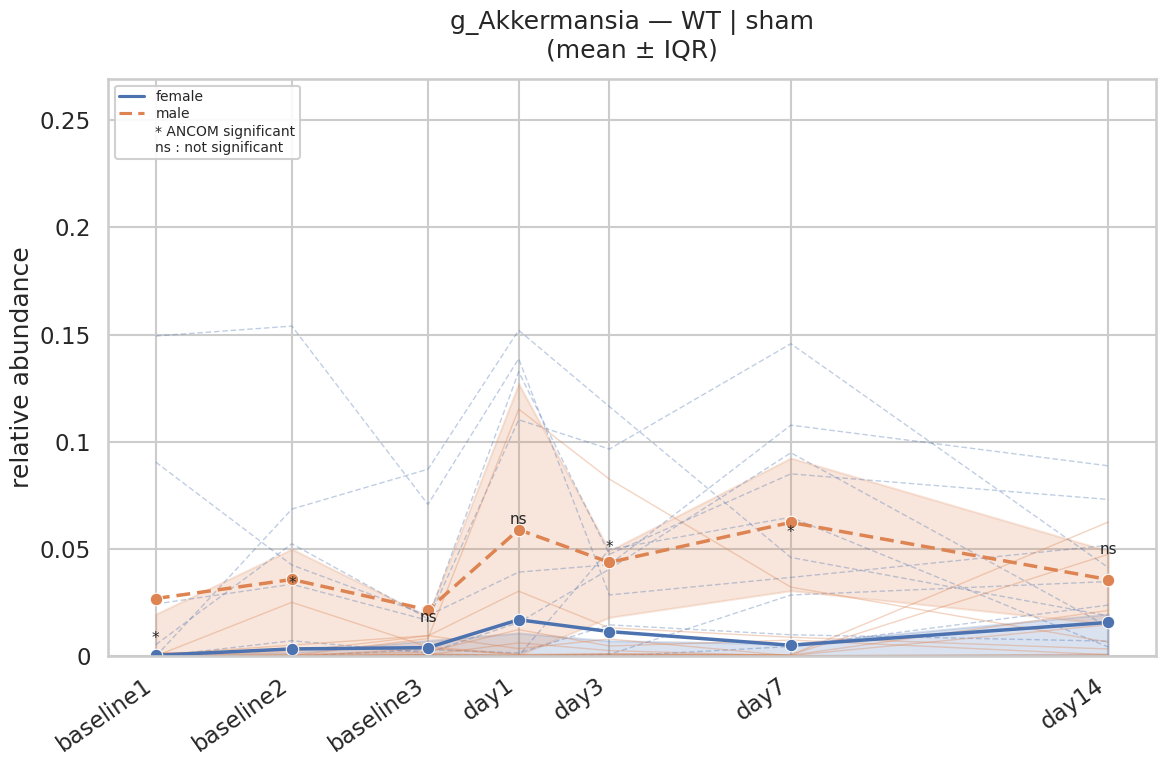

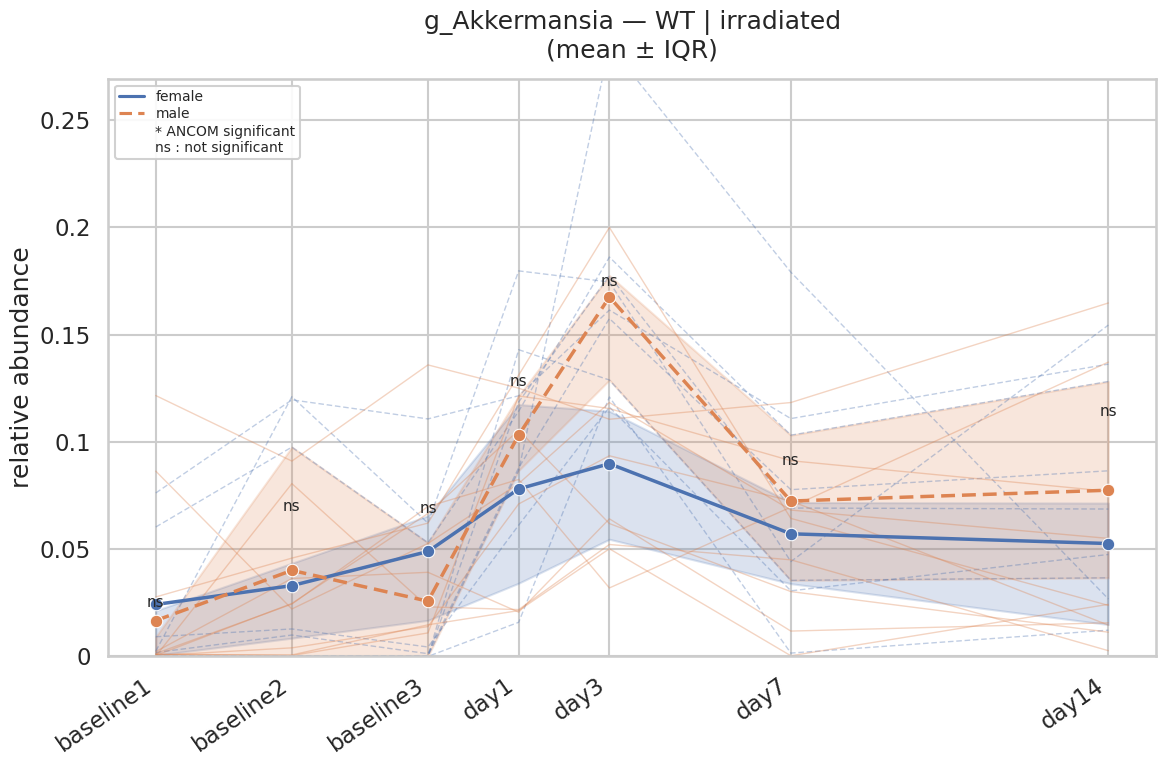

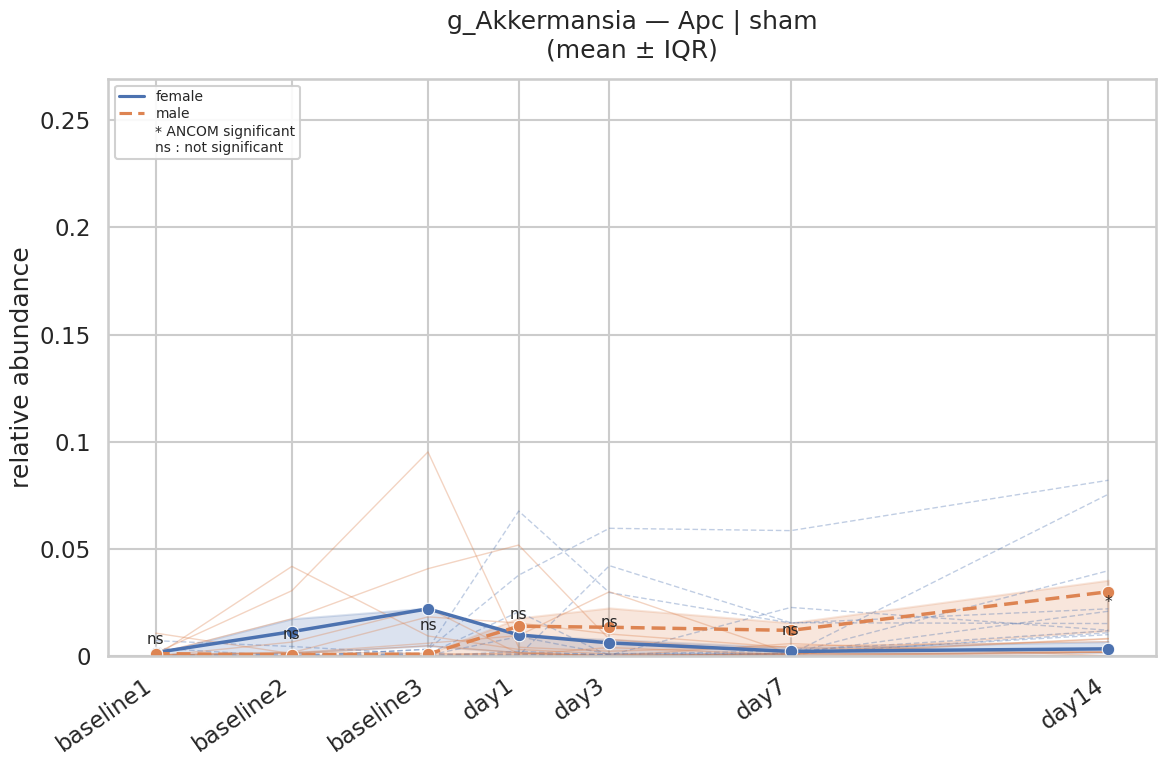

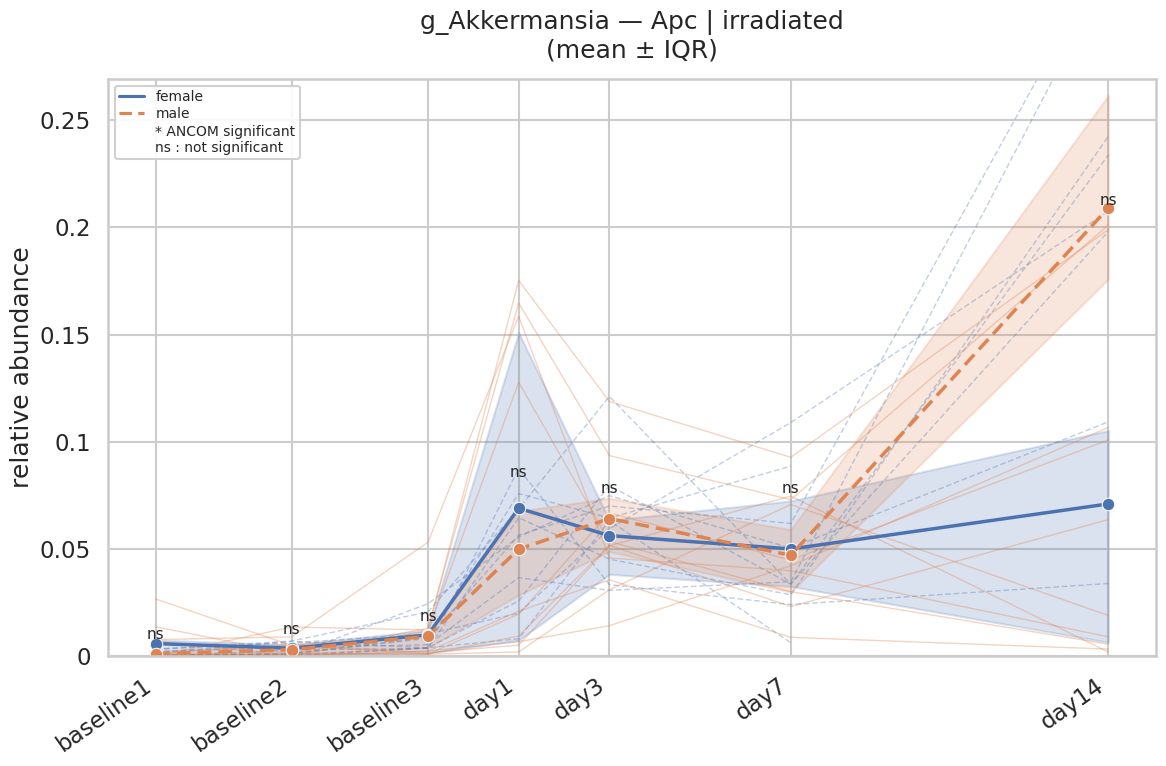

In [7]:
plotter.plot_taxon(
    taxon_query="g_Akkermansia",
    plot_mode="combo",
    comparison_levels=["female", "male"],
    combo_groups=[
        ("WT", "sham"),
        ("WT", "irradiated"),
        ("Apc", "sham"),
        ("Apc", "irradiated"),
    ],
)

In [8]:
from ancombc2_heatmaps import (
    ANCOMBC2HeatmapPlotter,
    HeatmapConfig,
    MetadataConfig,
    ComparisonConfig,
    PathConfig,
    SubsetSpec
)

heatmap_plotter = ANCOMBC2HeatmapPlotter(heatmap_config)

meta = heatmap_plotter.load_metadata()

subset = SubsetSpec(
    label="WT_sham_genus_ANCOM",
    title="WT | sham",
    filters={"mice_model": "WT", "description_of_treatment": "sham"}
)

heatmap_plotter.plot_subset(meta, subset)

NameError: name 'heatmap_config' is not defined